In [1]:
import os
import sys
#print(sys.executable)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
from scipy.signal import savgol_filter, find_peaks

from scipy.signal import savgol_filter
import random


In [2]:
Time = {}
CH1 = {}
CH2 = {}


for i in range(44,71):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

44
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0044.xlsx
45
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0045.xlsx
46
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0046.xlsx
47
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0047.xlsx
48
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0048.xlsx
49
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0049.xlsx
50
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0050.xlsx
51
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0051.xlsx
52
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0052.xlsx
53
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0053.xlsx
54
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0054.xlsx
55
True
Reading: C:/Users/ainch/OneDrive - 

In [11]:
for i in range(30,44):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

30
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0030.xlsx
31
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0031.xlsx
32
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0032.xlsx
33
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0033.xlsx
34
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0034.xlsx
35
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0035.xlsx
36
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0036.xlsx
37
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0037.xlsx
38
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0038.xlsx
39
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0039.xlsx
40
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0040.xlsx
41
True
Reading: C:/Users/ainch/OneDrive - 

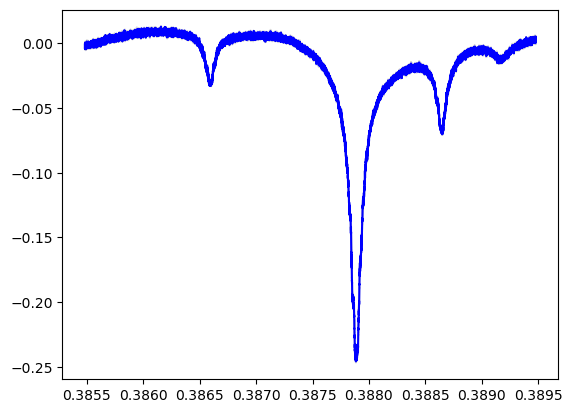

(np.float64(0.38870028), np.float64(-0.03873458114269901), np.float64(0.694711885780888), np.float64(0.685531))


In [3]:
# ================================
# 0. import
# ================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import interp1d


# ================================
# 1. 정렬 기준 계산 함수
# ================================
def get_center(t, y_s):
    peaks, _ = find_peaks(
        -y_s,
        prominence=np.std(y_s) * 0.2,
        distance=len(y_s) // 250
    )
    if len(peaks) == 0:
        return None

    idx = peaks[np.argmin(y_s[peaks])]
    return t[idx]


# ================================
# 2. 전처리 + 정렬 함수
# ================================
def process_trace(i, ref_center=None):

    t = Time[i].values
    y = CH1[i].values
    f = CH2[i].values

    # baseline 제거
    n = len(y)
    edge = n // 20
    mask = np.r_[np.arange(edge), np.arange(n-edge, n)]

    coef = np.polyfit(t[mask], y[mask], 1)
    y_corr = y - np.polyval(coef, t)

    # smoothing
    y_s = savgol_filter(y_corr, 11, 3)
    f_s = savgol_filter(f, 11, 3)

    # center 계산
    center = get_center(t, y_s)
    if center is None:
        return None

    # 정렬
    shift = 0 if ref_center is None else (center - ref_center)

    def shift_arr(arr):
        return interp1d(
            t, arr,
            bounds_error=False,
            fill_value=np.nan
        )(t - shift)

    y_corr = shift_arr(y_corr)
    y_s = shift_arr(y_s)
    f = shift_arr(f)
    f_s = shift_arr(f_s)

    return t, y_corr, y_s, f, f_s, center


# ================================
# 3. peak 추출 + 저장
# ================================
def extract_peaks(i, t, y_s, f, f_s, expected_peaks=6):

    peaks, _ = find_peaks(
        -y_s,
        prominence=np.std(y_s) * 0.2,
        distance=len(y_s) // 250
    )
    if len(peaks) == 0:
        return None

    # 중심 기준으로 가까운 것 선택
    center_idx = np.argmin(y_s[peaks])
    center_t = t[peaks][center_idx]

    order = np.argsort(np.abs(t[peaks] - center_t))
    peaks = np.sort(peaks[order[:expected_peaks]])

    T = t[peaks]
    Y = y_s[peaks]
    F = f_s[peaks]
    F_raw = f[peaks]

    # 저장
    globals()[f"data{i}_T"] = list(map(float, T))
    globals()[f"data{i}_1"] = list(map(float, Y))
    globals()[f"data{i}_2"] = list(map(float, F))
    globals()[f"data{i}_f"] = list(map(float, F_raw))

    return T, Y, F, F_raw


# ================================
# 4. 구간 최소값 찾기
# ================================
def find_min(t, y_corr, f_s, f, t_min, t_max):

    mask = (t >= t_min) & (t <= t_max)
    if np.sum(mask) == 0:
        return None

    idx_local = np.argmin(y_corr[mask])
    idx = np.where(mask)[0][idx_local]

    return t[idx], y_corr[idx], f_s[idx], f[idx]


# ================================
# 5. 그래프 (peak 포함)
# ================================
def plot_trace(i, ref_center=None):

    out = process_trace(i, ref_center)
    if out is None:
        return

    t, y_corr, y_s, f, f_s, center = out

    peak_data = extract_peaks(i, t, y_s, f, f_s)

    plt.plot(t, y_corr, color='gray', alpha=0.3)
    plt.plot(t, y_s, color='blue')

    if peak_data is not None:
        T, Y, _, _ = peak_data
        plt.scatter(T, Y, color='red')

    plt.show()


# ================================
# 6. 실행 (사용)
# ================================


# (1) 기준 trace에서 center 추출
base = process_trace(46)
ref_center = base[5]




# (2) 전체 데이터 처리 + peak 저장
for i in range(44, 47):
    out = process_trace(i, ref_center)
    if out is None:
        continue

    t, y_corr, y_s, f, f_s, center = out
    extract_peaks(i, t, y_s, f, f_s)

# (3) 그래프
plot_trace(44, ref_center)

# (4) 특정 구간 최소값
out = process_trace(44, ref_center)
t, y_corr, y_s, f, f_s, center = out

min_result = find_min(t, y_corr, f_s, f, 0.3887, 0.3890)
print(min_result)

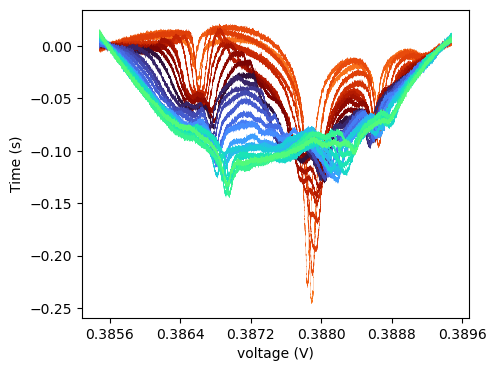

In [4]:
plt.figure(figsize=(5,4))
colors = plt.cm.turbo(np.linspace(0, 1, 40))
for i in range(44,71):
    t, y_corr, y_s, f, f_s, center = process_trace(i, ref_center=None)#정렬 안하는게 낮다
    plt.plot(t,y_s, color=colors[i-54] , lw =0.2)
plt.xlabel("voltage (V)")
plt.ylabel("Time (s)")
from matplotlib.ticker import MaxNLocator

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))  # 눈금 6개 이하로 제한

68
66
64
62
60
58
56
54
52
50
48
46
44


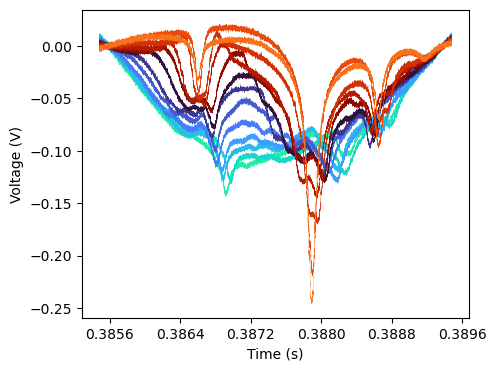

In [5]:
plt.figure(figsize=(5,4))
for i in range(68,43,-2):
    print(i)
    t, y_corr, y_s, f, f_s, center = process_trace(i, ref_center=None)#정렬 안하는게 낮다
    plt.plot(t,y_s,color =colors[i-54]  , lw =0.2)#color=np.random.rand(3,)
plt.ylabel("Voltage (V)")
plt.xlabel("Time (s)")
from matplotlib.ticker import MaxNLocator

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

36
37


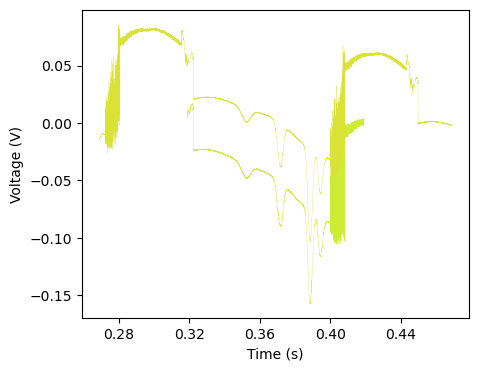

In [12]:
plt.figure(figsize=(5,4))
for i in [36,37]:
    print(i)
    t, y_corr, y_s, f, f_s, center = process_trace(i, ref_center=None)#정렬 안하는게 낮다
    plt.plot(t,y_s,color =colors[i-54]  , lw =0.2)#color=np.random.rand(3,)
plt.ylabel("Voltage (V)")
plt.xlabel("Time (s)")
from matplotlib.ticker import MaxNLocator

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

In [6]:
for i in range(44, 71):
    out = process_trace(i, ref_center)
    if out is None:
        continue

    t, y_corr, y_s, f, f_s, center = out
    extract_peaks(i, t, y_s, f, f_s)


[0.   0.01 0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6
 0.65 0.7  0.75 0.8  0.85 0.9  0.95 0.99 1.   1.05 1.1  1.15 1.2  0.1
 0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36 0.38
 0.4 ] 43
86 43


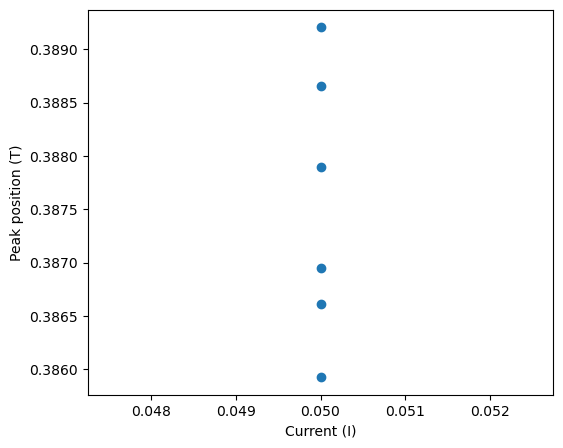

In [7]:
I = np.array([0, 0.01])
I = np.concatenate([I, np.linspace(0.05, 1.2, 24)])

idx = np.searchsorted(I, 0.99)   # 0.99이 들어갈 위치 계산
I = np.insert(I, idx, 0.99)
Y = np.linspace(0.1,0.4,16)
I = np.concatenate((I, Y))


print(I, len(I))

k = range(44, 87)   # 44 ~ 86
print(k[-1], len(k))
fig, ax = plt.subplots(figsize=(6,5))

for idx, k in enumerate(range(44, 71)):

    key = f"data{k}_T"

    if key not in globals():
        continue

    y_values = globals()[key]
    x_values = np.full(len(y_values), I[idx])

    ax.scatter(x_values, y_values)

ax.set_xlabel("Current (I)")
ax.set_ylabel("Peak position (T)")
plt.show()